In [11]:
from google.colab import files
uploaded = files.upload()

Saving breast_cancer_data.csv to breast_cancer_data.csv


In [14]:
from google.colab import files
uploaded = files.upload()

Saving spambase_data.csv to spambase_data.csv


In [27]:
from google.colab import files
uploaded = files.upload()

Saving credit_dataset.csv to credit_dataset.csv


In [30]:
from google.colab import files
uploaded = files.upload()

Saving 3class_data.csv to 3class_data.csv


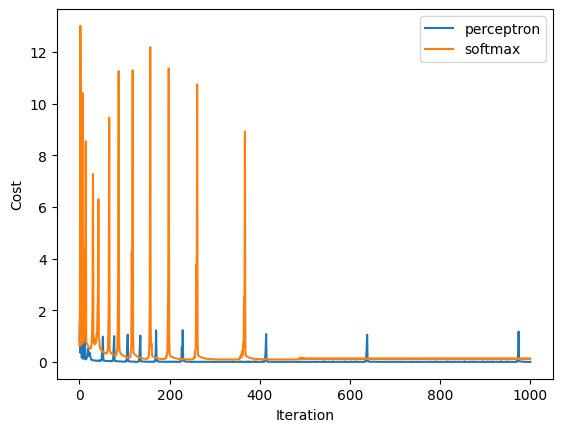

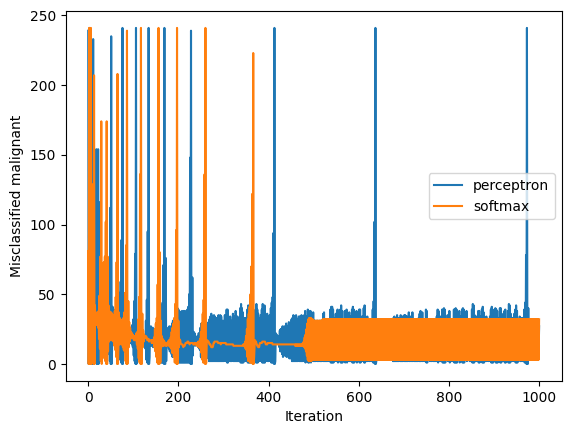

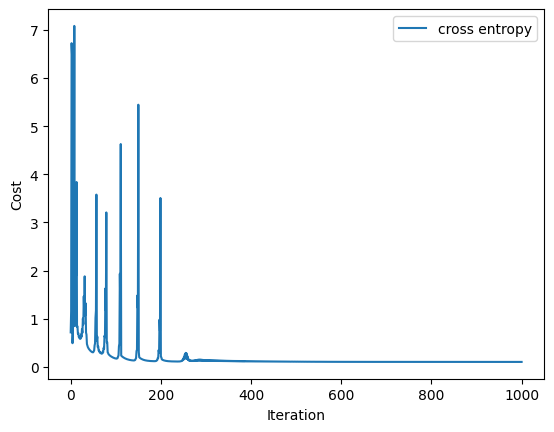

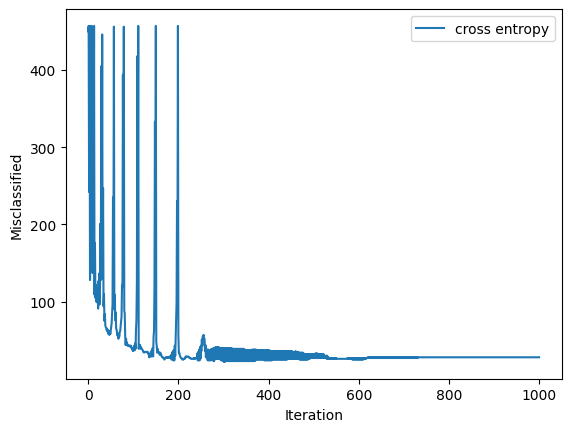

In [19]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
data = np.loadtxt('breast_cancer_data.csv', delimiter=',')
x = data[:-1, :]
y = data[-1:, :]
def model(x, w):
    return (w[0] + np.dot(x.T, w[1:])).T
def softmax_cost(w):
    return np.sum(np.log(1+np.exp(-y*model(x, w))))/float(np.size(y))
def perceptron_cost(w):
    return np.sum(np.maximum(0, -y*model(x, w)))/float(np.size(y))
def gradient_descent(f, w0, alpha, max_its):
    ws = [w0]
    costs = [f(w0)]
    g = grad(f)
    for i in range(max_its):
        w0 = w0 - alpha*g(w0)
        ws.append(w0)
        costs.append(f(w0))
    return np.array(ws), np.array(costs)
w0_p = 0.1*np.random.randn(9, 1)
ws_p, cost_p = gradient_descent(perceptron_cost, w0_p, 0.1, 1000)
w0_s = 0.1*np.random.randn(9, 1)
ws_s, cost_s = gradient_descent(softmax_cost, w0_s, 1.0, 1000)
def miscount(w, x, y):
    p = np.sign(model(x, w))
    m = (y.flatten()==-1)
    return np.sum(p.flatten()[m]!=-1)
mis_p = [miscount(v, x, y) for v in ws_p]
mis_s = [miscount(v, x, y) for v in ws_s]
plt.figure()
plt.plot(cost_p, label='perceptron')
plt.plot(cost_s, label='softmax')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.figure()
plt.plot(mis_p, label='perceptron')
plt.plot(mis_s, label='softmax')
plt.xlabel('Iteration')
plt.ylabel('Misclassified malignant')
plt.legend()
plt.show()
a = np.argwhere(y>0.9)
b = np.argwhere(y<-0.9)
yc = np.zeros(y.shape[1], dtype=int)
yc[a.flatten()] = 1
yc[b.flatten()] = 0
def sigmoid(t):
    return 1/(1+np.exp(-t))
lam = 2e-3
def cross_entropy(w):
    a = sigmoid(model(x, w))
    ind0 = np.argwhere(yc==0)
    c = -np.sum(np.log(1 - a[0, ind0.flatten()]))
    ind1 = np.argwhere(yc==1)
    c -= np.sum(np.log(a[0, ind1.flatten()]))
    c += lam*np.sum(w[1:]**2)
    return c/float(yc.size)
w0_l = 0.1*np.random.randn(9, 1)
ws_l, cost_l = gradient_descent(cross_entropy, w0_l, 0.6, 1000)
def miscount_logistic(w, x, yc):
    a = sigmoid(model(x, w))
    pred = (a>=0.5).astype(int)
    return np.sum(pred.flatten()!=yc)
mis_l = [miscount_logistic(v, x, yc) for v in ws_l]
plt.figure()
plt.plot(cost_l, label='cross entropy')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.figure()
plt.plot(mis_l, label='cross entropy')
plt.xlabel('Iteration')
plt.ylabel('Misclassified')
plt.legend()
plt.show()


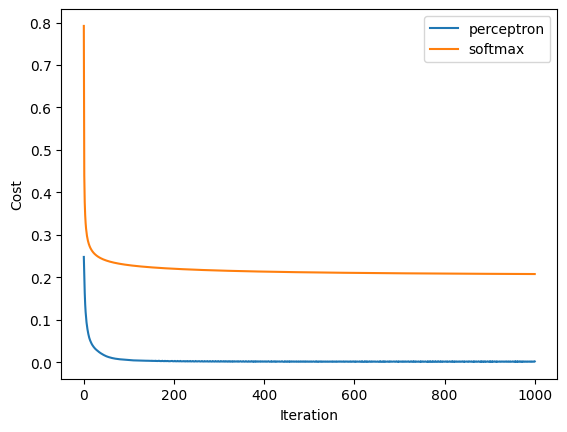

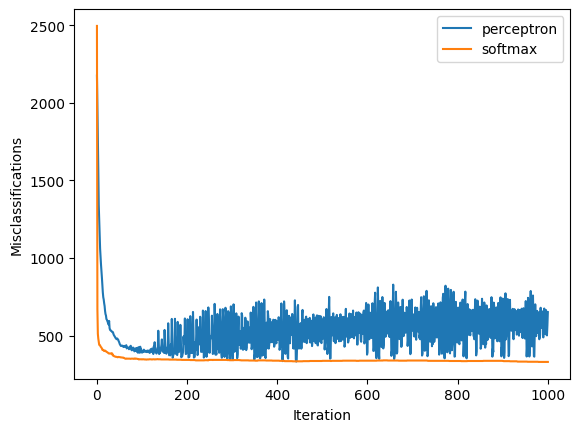

[[2662  126]
 [ 205 1608]]


In [20]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
def standard_normalizer(x):
    x_means = np.nanmean(x, axis=1)[:, None]
    x_stds = np.nanstd(x, axis=1)[:, None]
    ind = np.argwhere(x_stds < 1e-2)
    if len(ind) > 0:
        ind = [v[0] for v in ind]
        adjust = np.zeros(x_stds.shape)
        adjust[ind] = 1.0
        x_stds += adjust
    ind = np.argwhere(np.isnan(x))
    for i in ind:
        x[i[0], i[1]] = x_means[i[0], 0]
    normalizer = lambda data: (data - x_means)/x_stds
    inverse_normalizer = lambda data: data*x_stds + x_means
    return normalizer, inverse_normalizer
data = np.loadtxt('spambase_data.csv', delimiter=',')
x = data[:-1, :]
y = data[-1:, :]
norm, inv_norm = standard_normalizer(x)
x = norm(x)
x = np.vstack((np.ones((1, x.shape[1])), x))
def model(x, w):
    return np.dot(w.T, x)
def softmax_cost(w):
    return np.sum(np.log(1+np.exp(-y*model(x, w))))/float(np.size(y))
def perceptron_cost(w):
    return np.sum(np.maximum(0, -y*model(x, w)))/float(np.size(y))
def gradient_descent(f, w0, alpha, max_its):
    ws = [w0]
    costs = [f(w0)]
    g = grad(f)
    for i in range(max_its):
        w0 = w0 - alpha*g(w0)
        ws.append(w0)
        costs.append(f(w0))
    return np.array(ws), np.array(costs)
w0_p = 0.1*np.random.randn(x.shape[0], 1)
ws_p, cost_p = gradient_descent(perceptron_cost, w0_p, 0.1, 1000)
w0_s = 0.1*np.random.randn(x.shape[0], 1)
ws_s, cost_s = gradient_descent(softmax_cost, w0_s, 1.0, 1000)
def miscount(w, x, y):
    pred = np.sign(model(x, w))
    return np.sum(pred != y)
mis_p = [miscount(v, x, y) for v in ws_p]
mis_s = [miscount(v, x, y) for v in ws_s]
plt.figure()
plt.plot(cost_p, label='perceptron')
plt.plot(cost_s, label='softmax')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.figure()
plt.plot(mis_p, label='perceptron')
plt.plot(mis_s, label='softmax')
plt.xlabel('Iteration')
plt.ylabel('Misclassifications')
plt.legend()
plt.show()
best_mis_p = np.min(mis_p)
best_mis_s = np.min(mis_s)
total = x.shape[1]
acc_p = 1 - best_mis_p/total
acc_s = 1 - best_mis_s/total
best_idx = np.argmin(mis_s)
best_w = ws_s[best_idx]
pred = np.sign(model(x, best_w))
tp = np.sum((pred==1) & (y==1))
tn = np.sum((pred==-1) & (y==-1))
fp = np.sum((pred==1) & (y==-1))
fn = np.sum((pred==-1) & (y==1))
confusion = np.array([[tn, fp],[fn, tp]])
print(confusion)


In [25]:
from ucimlrepo import fetch_ucirepo
import pandas as pd
import time
import numpy as np
import matplotlib.pyplot as plt
last_exception = None
attempts = 0
while attempts < 3:
    try:
        bc = fetch_ucirepo(id=15)
        sp = fetch_ucirepo(id=94)
        X = bc.data.features.drop(['Single epithelial cell size'], axis=1)
        y = bc.data.targets.replace({2:1, 4:-1})
        print("Data fetched from repository:")
        print(X.head())
        print(y.head())
        break
    except Exception as e:
        last_exception = e
        attempts += 1
        time.sleep(2)
if attempts == 3:
    print("Using local file due to error:", last_exception)
    data = np.loadtxt('breast_cancer_data.csv', delimiter=',')
    X = data[:-1, :]
    y = data[-1, :]
    print("Local file data (first 5 individuals):")
    print(X[:, :5])
    print(y[:5])


Using local file due to error: Error connecting to server
Local file data (first 5 individuals):
[[5. 5. 3. 6. 4.]
 [1. 4. 1. 8. 1.]
 [1. 4. 1. 8. 1.]
 [1. 5. 1. 1. 3.]
 [2. 7. 2. 3. 2.]
 [3. 3. 3. 3. 3.]
 [1. 2. 1. 7. 1.]
 [1. 1. 1. 1. 1.]]
[1. 1. 1. 1. 1.]


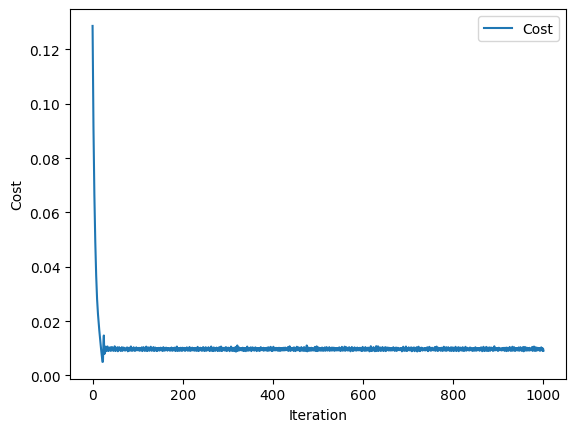

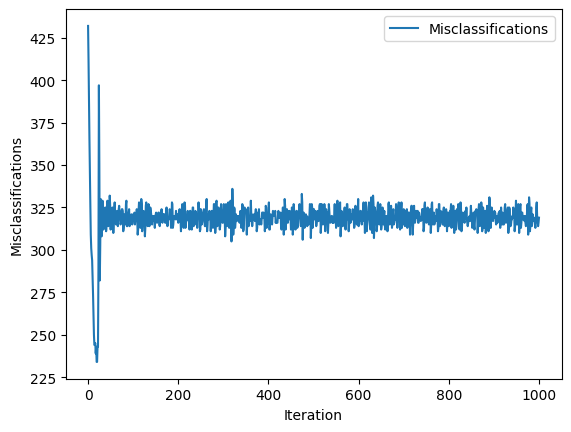

[[148 152]
 [ 82 618]]


In [28]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
data = np.loadtxt('credit_dataset.csv', delimiter=',')
x = data[:-1, :]
y = data[-1:, :]
def standard_normalizer(x):
    x_means = np.nanmean(x, axis=1)[:, None]
    x_stds = np.nanstd(x, axis=1)[:, None]
    ind = np.argwhere(x_stds < 1e-2)
    if len(ind) > 0:
        ind = [v[0] for v in ind]
        adjust = np.zeros(x_stds.shape)
        adjust[ind] = 1.0
        x_stds += adjust
    ind = np.argwhere(np.isnan(x))
    for i in ind:
        x[i[0], i[1]] = x_means[i[0], 0]
    normalizer = lambda data: (data - x_means)/x_stds
    return normalizer
norm = standard_normalizer(x)
x = norm(x)
x = np.vstack((np.ones((1, x.shape[1])), x))
def model(x, w):
    return np.dot(w.T, x)
def perceptron_cost(w):
    return np.sum(np.maximum(0, -y*model(x, w)))/float(np.size(y))
def gradient_descent(f, w0, alpha, max_its):
    ws = [w0]
    costs = [f(w0)]
    g = grad(f)
    for i in range(max_its):
        w0 = w0 - alpha*g(w0)
        ws.append(w0)
        costs.append(f(w0))
    return np.array(ws), np.array(costs)
w0 = 0.1*np.random.randn(x.shape[0], 1)
ws, cost_history = gradient_descent(perceptron_cost, w0, 0.1, 1000)
def miscount(w, x, y):
    return np.sum(np.sign(model(x, w)) != y)
mis_history = [miscount(v, x, y) for v in ws]
plt.figure()
plt.plot(cost_history, label='Cost')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.figure()
plt.plot(mis_history, label='Misclassifications')
plt.xlabel('Iteration')
plt.ylabel('Misclassifications')
plt.legend()
plt.show()
best_idx = np.argmin(mis_history)
best_w = ws[best_idx]
pred = np.sign(model(x, best_w))
tp = np.sum((pred==1) & (y==1))
tn = np.sum((pred==-1) & (y==-1))
fp = np.sum((pred==1) & (y==-1))
fn = np.sum((pred==-1) & (y==1))
confusion = np.array([[tn, fp],[fn, tp]])
print(confusion)


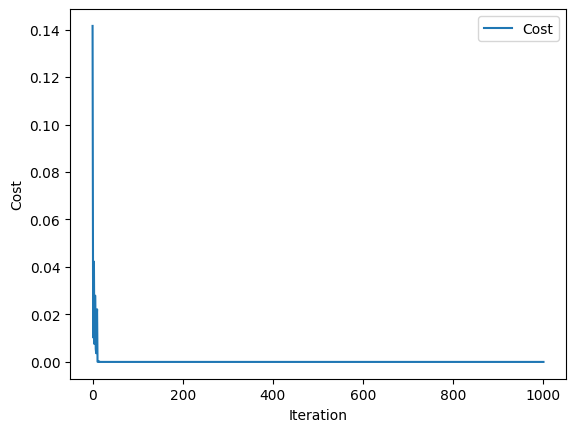

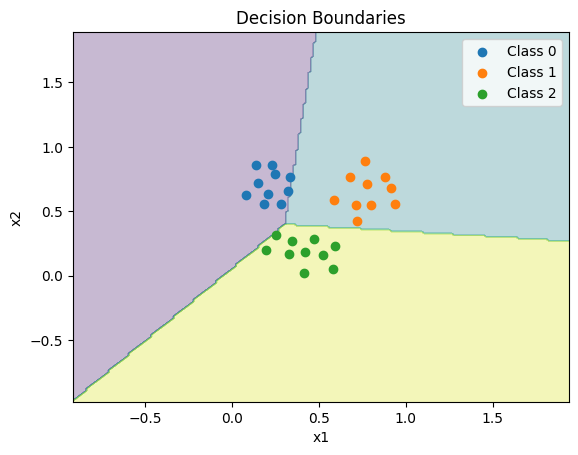

In [34]:
import autograd.numpy as np
from autograd import grad
import matplotlib.pyplot as plt
data = np.loadtxt('3class_data.csv', delimiter=',')
x = data[:-1, :]
y = data[-1, :].astype(int)
def model(x, w):
    return w[0:1, :].T + np.dot(w[1:, :].T, x)
lam = 1e-5
def multiclass_perceptron(w):
    all_evals = model(x, w)
    a = np.max(all_evals, axis=0)
    b = all_evals[y, np.arange(np.size(y))]
    cost = np.sum(a - b)
    cost = cost + lam*np.linalg.norm(w[1:, :], 'fro')**2
    return cost/float(np.size(y))
def gradient_descent(f, w0, alpha, max_its):
    ws = [w0]
    costs = [f(w0)]
    g = grad(f)
    for i in range(max_its):
        w0 = w0 - alpha*g(w0)
        ws.append(w0)
        costs.append(f(w0))
    return np.array(ws), np.array(costs)
w0 = 0.1*np.random.randn(3, 3)
ws, cost_history = gradient_descent(multiclass_perceptron, w0, 0.1, 1000)
plt.figure()
plt.plot(cost_history, label='Cost')
plt.xlabel('Iteration')
plt.ylabel('Cost')
plt.legend()
plt.show()
xmin = np.min(x[0, :])-1
xmax = np.max(x[0, :])+1
ymin = np.min(x[1, :])-1
ymax = np.max(x[1, :])+1
xx, yy = np.meshgrid(np.linspace(xmin, xmax, 200), np.linspace(ymin, ymax, 200))
grid = np.vstack((xx.ravel(), yy.ravel()))
w_best = ws[np.argmin(cost_history)]
scores = model(grid, w_best)
pred_grid = np.argmax(scores, axis=0)
plt.figure()
plt.contourf(xx, yy, pred_grid.reshape(xx.shape), alpha=0.3)
for cl in np.unique(y):
    idx = np.where(y==cl)
    plt.scatter(x[0, idx], x[1, idx], label='Class '+str(cl))
plt.legend()
plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Decision Boundaries')
plt.show()


This assignment focuses on implementing classification techniques for both binary and multi-class problems. It involves comparing cost functions (softmax, perceptron, and cross entropy) and applying gradient descent to optimize the weights for classifying breast cancer and spam data. Additionally, it includes accessing datasets from the UC Irvine repository with a local fallback, performing credit checks using normalized data, and implementing a multiclass perceptron with regularization to visualize decision boundaries. Each problem is solved in a separate code cell in Python, with the results evaluated through cost history plots, misclassification counts, and confusion matrices to assess performance and accuracy.